In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import date, timedelta, datetime
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter
INST = ["COP", "GOV", "INS", "JUD", "MIL", "OPP", "REB", "SEP", "SPY", "UAF", "AGR", "BUS", "CRM", "CVL", "DEV", "EDU", "ELI", "ENV", "HLH", "HRI", "LAB", "LEG", "MED", "REF", "MOD", "RAD"]

In [2]:
# import changepoints
tire_cps = np.array(np.load("model_codes/TIRE/experiment1_ws50.npy", allow_pickle=True).item()['both'])
tire_cps = np.nan_to_num(tire_cps, nan=0.0, copy=False)
print(tire_cps.shape)

tscp2_cps = pd.read_csv("model_codes/TSCP2/src/experiment0.csv").to_numpy()
tscp2_cps = np.pad(tscp2_cps, pad_width=((0,0), (49, 50)), mode='constant', constant_values=0)
print(tscp2_cps.shape)
t_cps = np.empty(len(tscp2_cps), dtype=object)
for i in range(len(tscp2_cps)):
    t_cps[i] = find_peaks(tscp2_cps[i],height=1,prominence=1)[0]
t_zeros = np.zeros((t_cps.shape[0], 489))
for i in range(t_cps.shape[0]):
    t_zeros[i, t_cps[i]] = 1

snts_cps = np.load("model_codes/SN-ts2vec/pred_cp_window50.npy", allow_pickle=True)
s_zeros = np.zeros((snts_cps.shape[0], 489))
print(s_zeros.shape)
for i in range(snts_cps.shape[0]):
    s_zeros[i, snts_cps[i]] = 1

rpt_cps = np.load("gdelt/ruptures/ruptures_window_cp.npy")
rpt_cps = rpt_cps[:, :-1]
print(rpt_cps.shape)

(224, 489)
(224, 489)
(224, 489)
(224, 489)


In [3]:
data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
data_dir = Path(r"../data/input_datasets/weekly_pw_filtered_features")
cols = ["mentions", "events", "avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_raw_text", "avg_root_event", "avg_len", "avg_goldstein", "avg_tone", "avg_confidence", "avg_lat1", "avg_lon1", "avg_lat2", "avg_lon2", "avg_lata", "avg_lona", 
            "total_num_mentions", "total_num_sources", "total_num_articles"]

all_data = []
mean_mentions = []
min_mentions = []
max_mentions = []
names = []
indices = []
for i, csv_file in enumerate(data_dir.glob("*.csv")):
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    X = ws_pp[cols].to_numpy()
    all_data.append(X)
    #X = (X - X.mean(axis=0)) / X.std(axis=0)
    mean_mentions.append(np.mean(ws_pp["mentions"]))
    min_mentions.append(np.min(ws_pp["mentions"]))
    max_mentions.append(np.max(ws_pp["mentions"]))
    names.append(csv_file.stem)
    indices.append(i)

all_data = np.array(all_data)
mentions_df = pd.DataFrame({"name": names, "mean_mentions": mean_mentions, "min_mentions": min_mentions, "max_mentions": max_mentions, "index": indices})

In [4]:
mentions_df
# extract types from the names
mentions_df["a1"] = mentions_df["name"].apply(lambda x: x.split("_")[0])
mentions_df["a2"] = mentions_df["name"].apply(lambda x: x.split("_")[1])

mentions_df["type"] = mentions_df.apply(lambda row: "INST-INST" if row["a1"][-3:] in INST and row["a2"][-3:] in INST else ("INST-GEO" if (row["a1"][-3:] in INST) ^ (row["a2"][-3:] in INST) else "GEO-GEO"), axis=1)
mentions_df

,name,mean_mentions,min_mentions,max_mentions,index,a1,a2,type
0,AFR_GOV_data,636.063395,100,3902,0,AFR,GOV,INST-GEO
1,AFR_USA_data,851.676892,129,5088,1,AFR,USA,GEO-GEO
2,AFR_ZAF_data,619.813906,147,4740,2,AFR,ZAF,GEO-GEO
3,AUS_BUS_data,988.664622,134,3353,3,AUS,BUS,INST-GEO
4,AUS_GOV_data,1846.292434,189,7574,4,AUS,GOV,INST-GEO
...,...,...,...,...,...,...,...,...
219,USA_USAHLH_data,605.867076,105,3099,219,USA,USAHLH,INST-GEO
220,USA_USAJUD_data,3567.932515,514,10345,220,USA,USAJUD,INST-GEO
221,USA_USALEG_data,2491.728016,397,14720,221,USA,USALEG,INST-GEO
222,USA_USAMED_data,3984.527607,730,13905,222,USA,USAMED,INST-GEO


In [5]:
# top max_mentions by type and show the top 5 for each type, don't
top_5_by_type = {}
for t, group in mentions_df.groupby("type"):
    top_5_by_type[t] = group.nlargest(5, "max_mentions").reset_index(drop=True)[["name", "max_mentions", "index"]]
top_5_by_type

{'GEO-GEO':            name  max_mentions  index
 0  ISR_PSE_data         74479    120
 1  IRN_USA_data         59125    117
 2  USA_IRN_data         58911    197
 3  PSE_ISR_data         54469    159
 4  USA_RUS_data         40072    211,
 'INST-GEO':            name  max_mentions  index
 0  USA_COP_data         91185    186
 1  COP_USA_data         86566     39
 2  USA_GOV_data         85412    195
 3  GOV_USA_data         78852    109
 4  USA_EDU_data         73232    190,
 'INST-INST':               name  max_mentions  index
 0     GOV_LEG_data         25586     98
 1     JUD_GOV_data         22793    128
 2  GOV_USAGOV_data         20458    107
 3  USAGOV_GOV_data         18226    175
 4     LEG_GOV_data         17644    136}

In [6]:
top_5_by_type["GEO-GEO"]

,name,max_mentions,index
0,ISR_PSE_data,74479,120
1,IRN_USA_data,59125,117
2,USA_IRN_data,58911,197
3,PSE_ISR_data,54469,159
4,USA_RUS_data,40072,211


In [7]:
df["avg_tone"]

0     -2.771461
1     -2.503662
2     -2.626858
3     -1.958450
4     -2.630213
         ...   
484   -2.208108
485   -2.267909
486   -2.342246
487   -3.513923
488   -3.772059
Name: avg_tone, Length: 489, dtype: float64

In [8]:
def minmax(x):
    return (x - x.min()) / (x.max() - x.min())

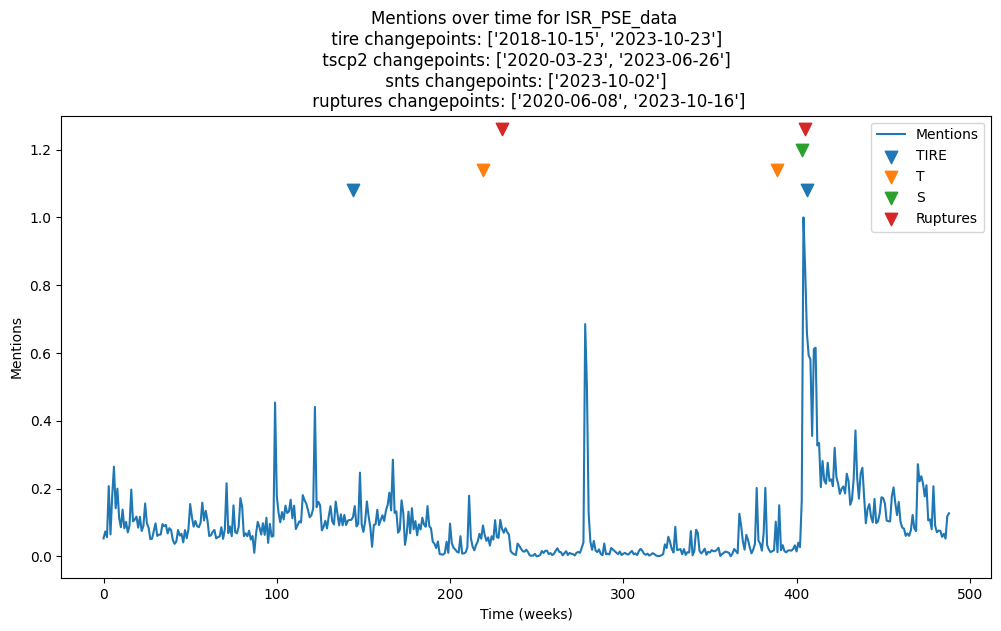

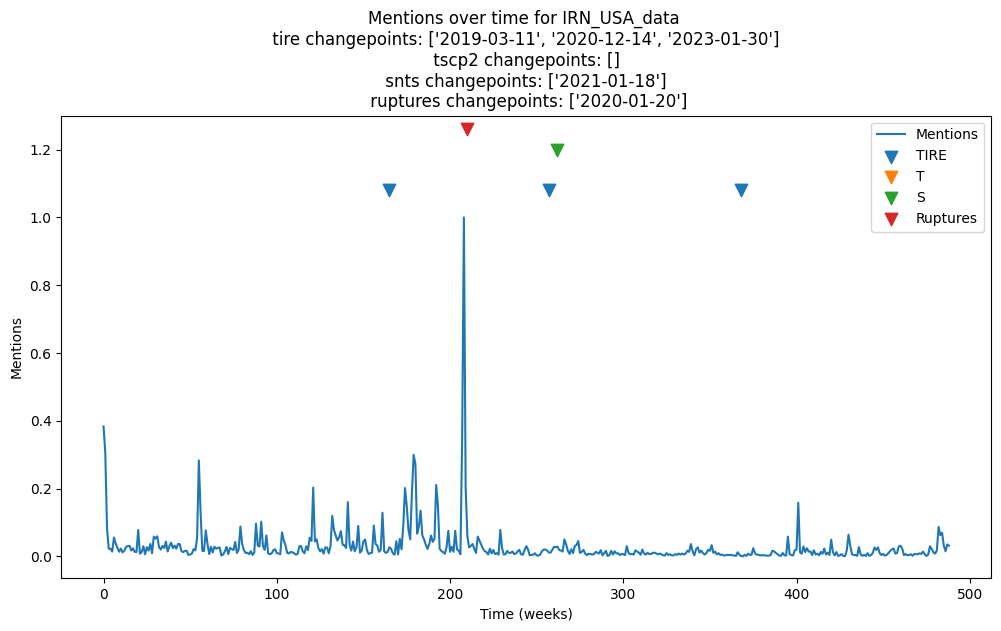

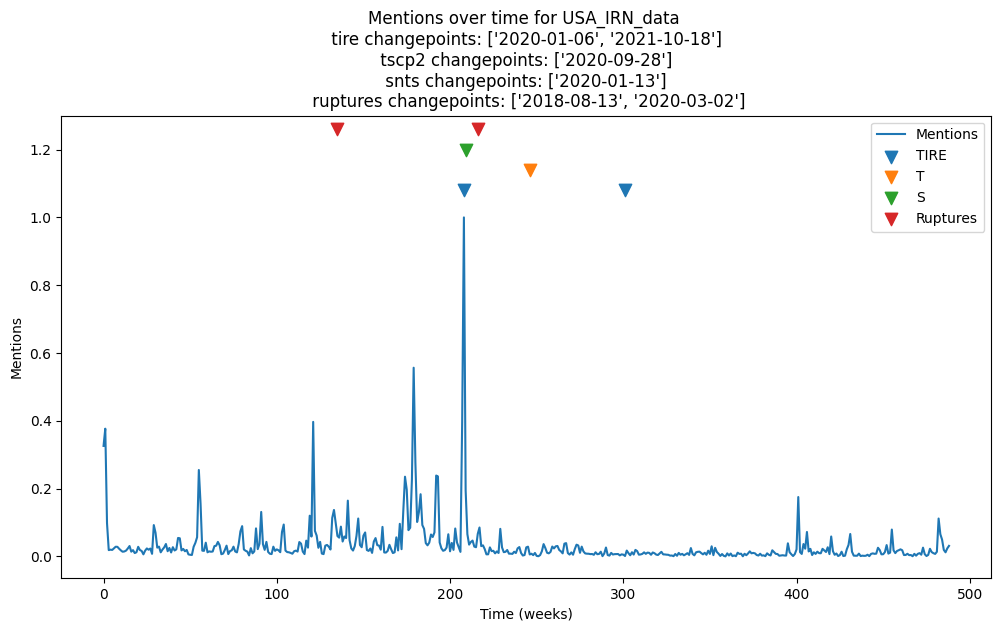

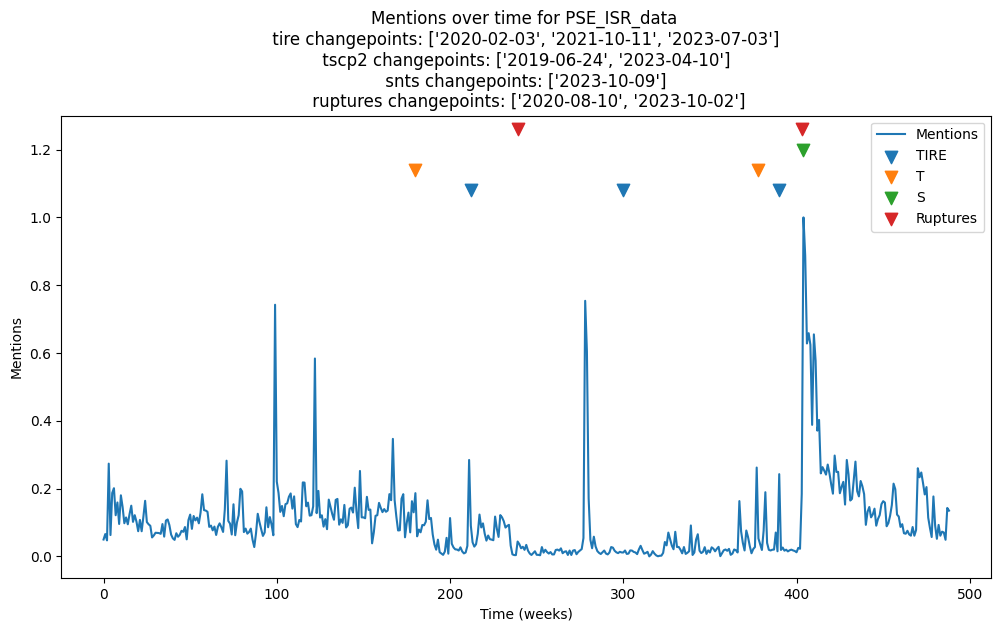

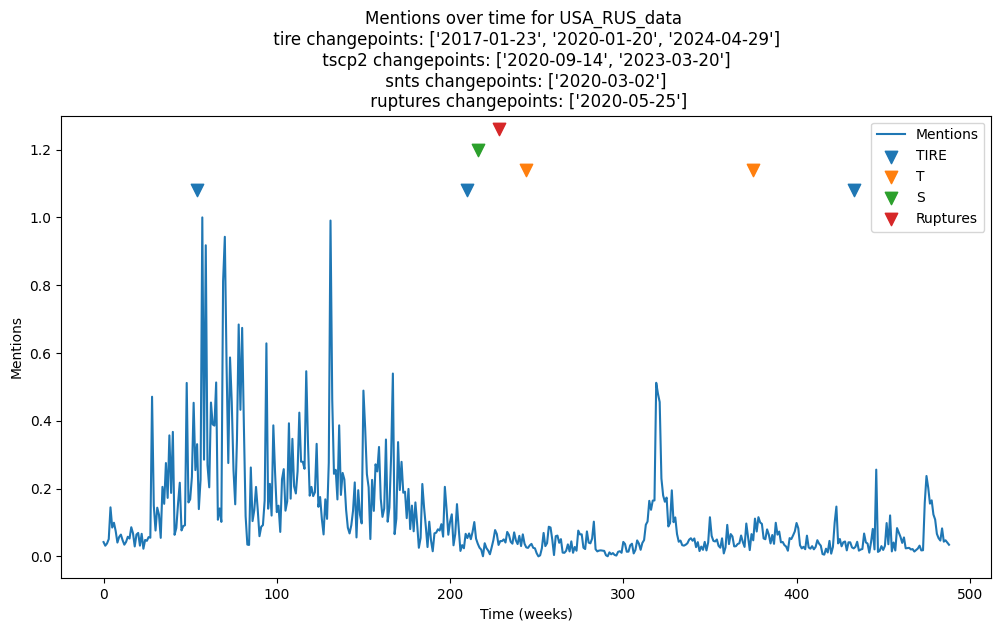

In [9]:
for _, pair in top_5_by_type["GEO-GEO"].iterrows():
    name = pair["name"]
    index = pair["index"]

    # Get changepoint indices
    tire_cp = np.flatnonzero(tire_cps[index])
    t_cp    = np.flatnonzero(t_zeros[index])
    s_cp    = np.flatnonzero(s_zeros[index])
    rupt_cp = np.flatnonzero(rpt_cps[index])

    df = pd.read_csv(data_dir / f"{name}.csv")

    fig, ax = plt.subplots(figsize=(12, 6))

    # Main time series
    # normalize the series for better visualization
    ax.plot(minmax(df["mentions"]), label="Mentions")
    #ax.plot(minmax(df["avg_len"]), label="Average Length")
    #ax.plot(minmax(df["avg_tone"]), label="Average Tone")
    #ax.plot(minmax(df["avg_root_event"]), label="Average Root Event")

    # Changepoints as markers at different vertical positions
    ymax = 1

    ax.scatter(tire_cp, [ymax * 1.08] * len(tire_cp),
               marker="v", s=80, label="TIRE")

    ax.scatter(t_cp, [ymax * 1.14] * len(t_cp),
               marker="v", s=80, label="T")

    ax.scatter(s_cp, [ymax * 1.20] * len(s_cp),
               marker="v", s=80, label="S")

    ax.scatter(rupt_cp, [ymax * 1.26] * len(rupt_cp),
               marker="v", s=80, label="Ruptures")

    ax.set_ylim(top=ymax * 1.3)

    ax.set_title(f"Mentions over time for {name} \n tire changepoints: {[df['week'].iloc[i] for i in tire_cp]} \n tscp2 changepoints: {[df['week'].iloc[i] for i in t_cp]} \n snts changepoints: {[df['week'].iloc[i] for i in s_cp]} \n ruptures changepoints: {[df['week'].iloc[i] for i in rupt_cp]}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Mentions")
    ax.legend()

    plt.show()

# Evaluation

## GEO-GEO

- For the 5 actor pairs with the most mentions across every period, we consider the change points generated.
- These five actor pairs contain two reciprocal pairs (USA-Iran and Iran-USA as well as Palestine-Israel / Israel-Palestine, additionally USA-Russia)
- For ISR-PSE:
    - SN-TS2Vec across both this and the inverse pair flags October 7th as a change point, consistently with Ruptures
    - TIRE and TSCP2 recognise a change point around the same time, but earlier
- For IRN-USA / USA-IRN:
    - SN-TS2Vec and Ruptures both flag January 2021 as change points. This coincides with a change in the US Presidency and Government from Donald Trump to Joe Biden, who harbor vastly different policies towards Iran (this coincides with what we are interested in for change points)
    - Ruptures and TIRE flag January 2020, which coincides with a spike of attention / mentions following the assassination of Quassem Suleimani
- For USA-Russia:
    - Ruptures: 7/2016 - Election campaigns in the United States, 1/2022 - time leading up to the invasion of Ukraine by Russia (also SNTS2Vec and arguably TIRE)
    - TSCP2: 12/2016 - change in US presidency 

## GEO-INST

- USA-COP
    - between March-August 2020 - consensus across models (police protests in US)
- COP-USA
    - same consensus as above, plus cp for ruptures in September 2018
    - TSCP2: cp in April 2023    
- USA-GOV
    - snts & rup -> 01/21, change in US presidency
    - rup -> 11/16, US presidential election, 03/20 -> covid
- GOV-USA
    - rup -> same as USA-GOV + January 2019 (maybe related to government shutdown)
    - tscp2: 

## INST-INST

- For USAGOV-USA and vice-versa:
    - Ruptures at changes in US presidency
    - other models specifically in 2021 change
- For GOV-LEG:
    - agreement across all models in late 2019/ early 2020
- For LEG-GOV:
    - near agreement in early 2023
    - early 2020 and early 2017 for ruptures


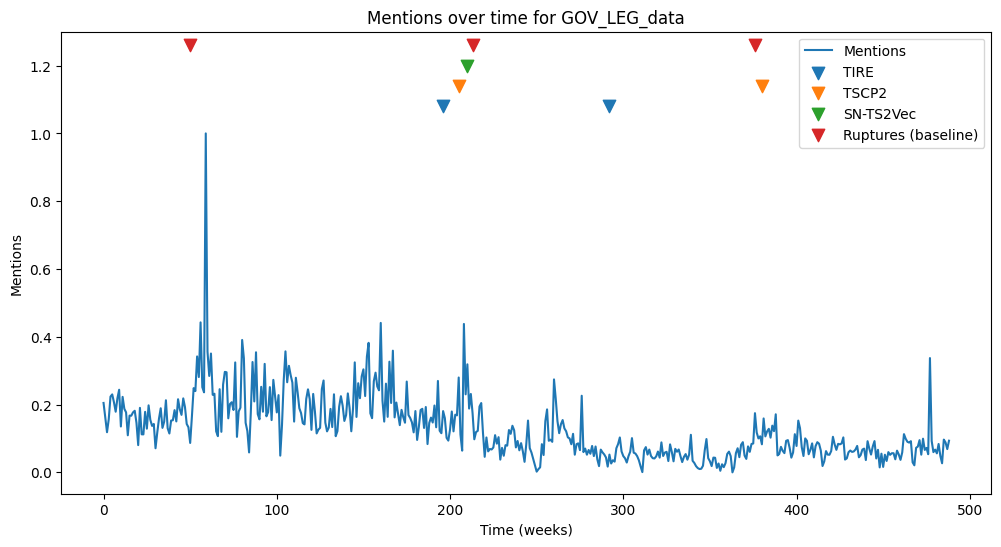

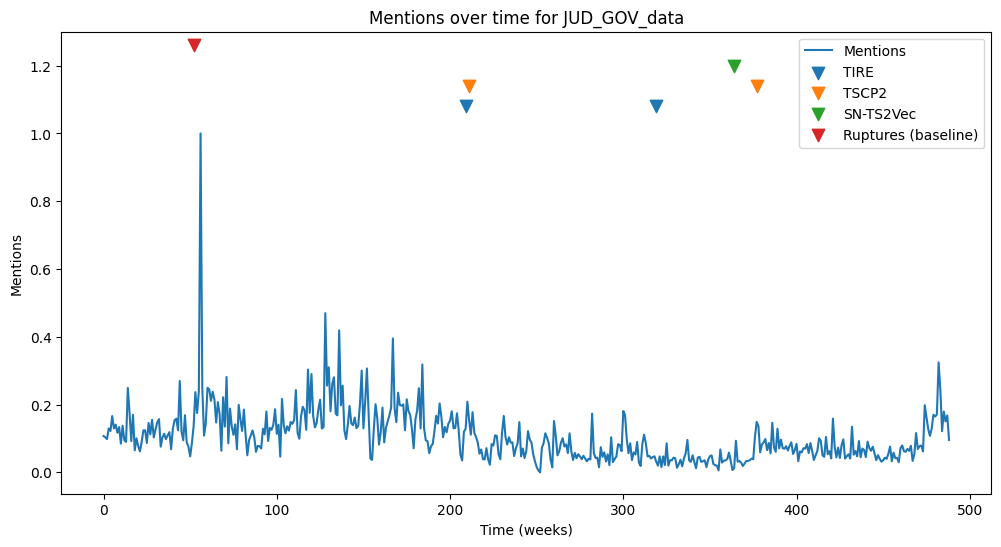

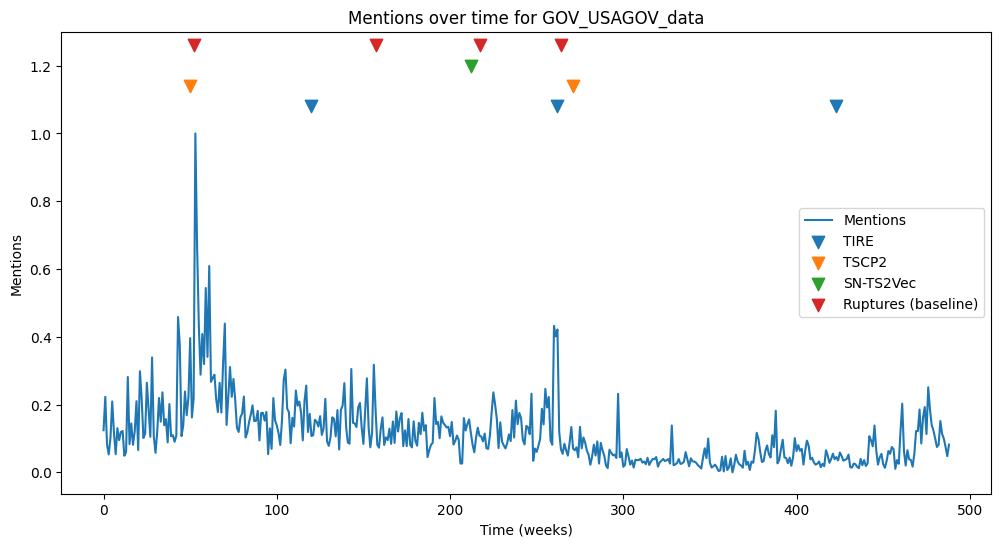

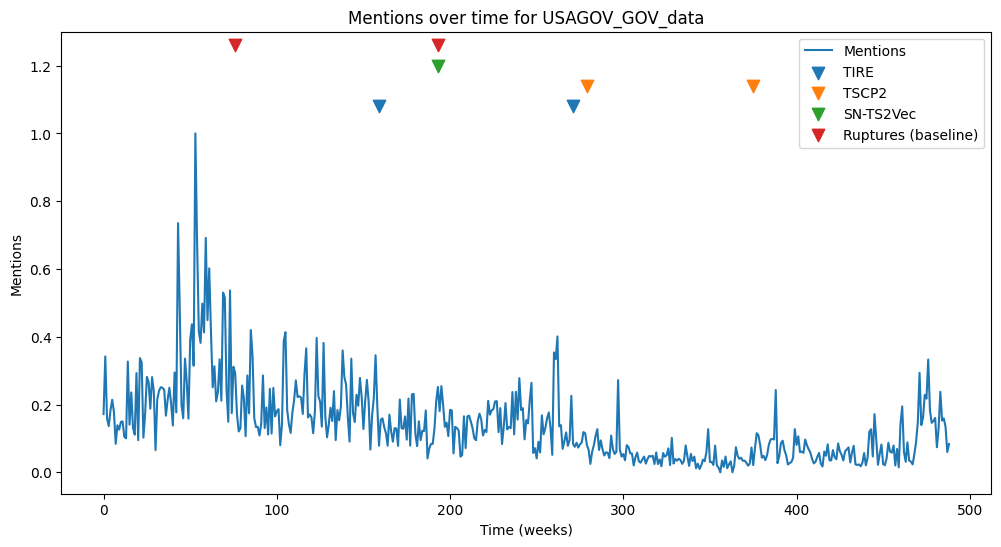

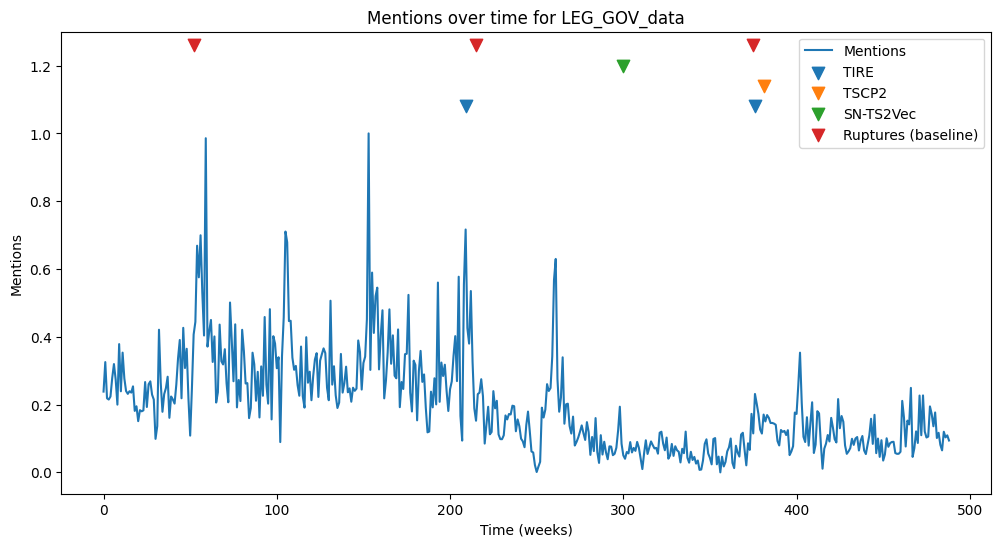

In [10]:
for _, pair in top_5_by_type["INST-INST"].iterrows():
    name = pair["name"]
    index = pair["index"]

    # Get changepoint indices
    tire_cp = np.flatnonzero(tire_cps[index])
    t_cp    = np.flatnonzero(t_zeros[index])
    s_cp    = np.flatnonzero(s_zeros[index])
    rupt_cp = np.flatnonzero(rpt_cps[index])

    df = pd.read_csv(data_dir / f"{name}.csv")

    fig, ax = plt.subplots(figsize=(12, 6))

    # Main time series
    # normalize the series for better visualization
    ax.plot(minmax(df["mentions"]), label="Mentions")
    #ax.plot(minmax(df["avg_len"]), label="Average Length")
    #ax.plot(minmax(df["avg_tone"]), label="Average Tone")
    #ax.plot(minmax(df["avg_root_event"]), label="Average Root Event")

    # Changepoints as markers at different vertical positions
    ymax = 1

    ax.scatter(tire_cp, [ymax * 1.08] * len(tire_cp),
               marker="v", s=80, label="TIRE")

    ax.scatter(t_cp, [ymax * 1.14] * len(t_cp),
               marker="v", s=80, label="TSCP2")

    ax.scatter(s_cp, [ymax * 1.20] * len(s_cp),
               marker="v", s=80, label="SN-TS2Vec")

    ax.scatter(rupt_cp, [ymax * 1.26] * len(rupt_cp),
               marker="v", s=80, label="Ruptures (baseline)")

    ax.set_ylim(top=ymax * 1.3)

    #ax.set_title(f"Mentions over time for {name} \n tire changepoints: {[df['week'].iloc[i] for i in tire_cp]} \n tscp2 changepoints: {[df['week'].iloc[i] for i in t_cp]} \n snts changepoints: {[df['week'].iloc[i] for i in s_cp]} \n ruptures changepoints: {[df['week'].iloc[i] for i in rupt_cp]}")
    ax.set_title(f"Mentions over time for {name}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Mentions")
    ax.legend()

    plt.show()

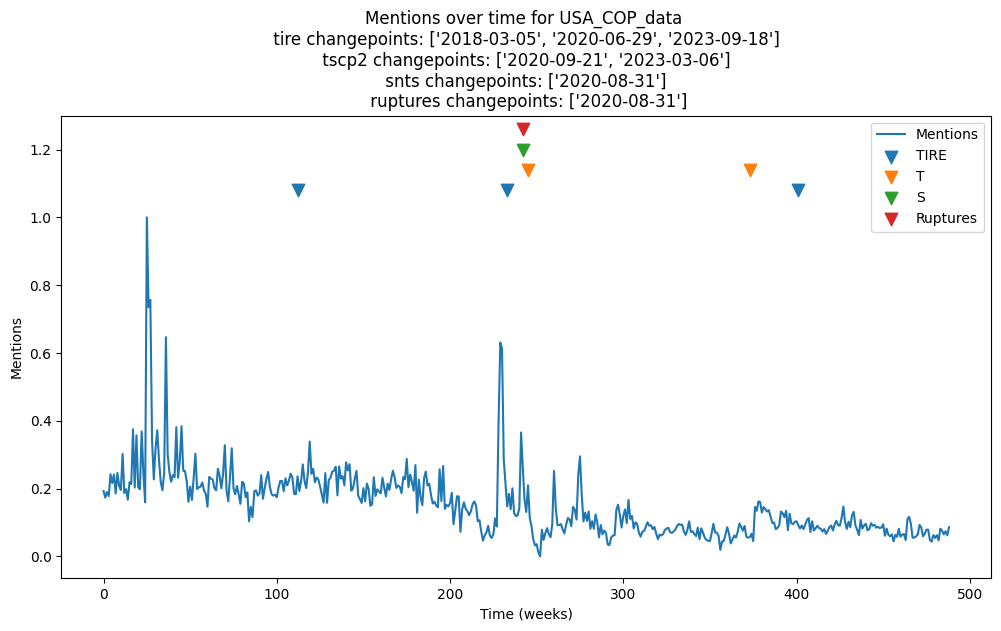

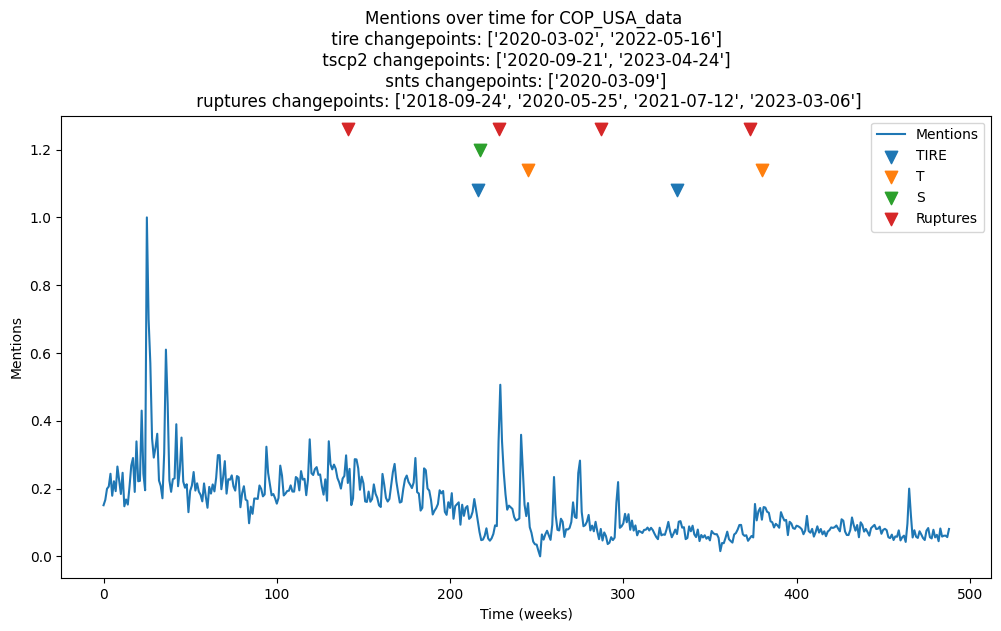

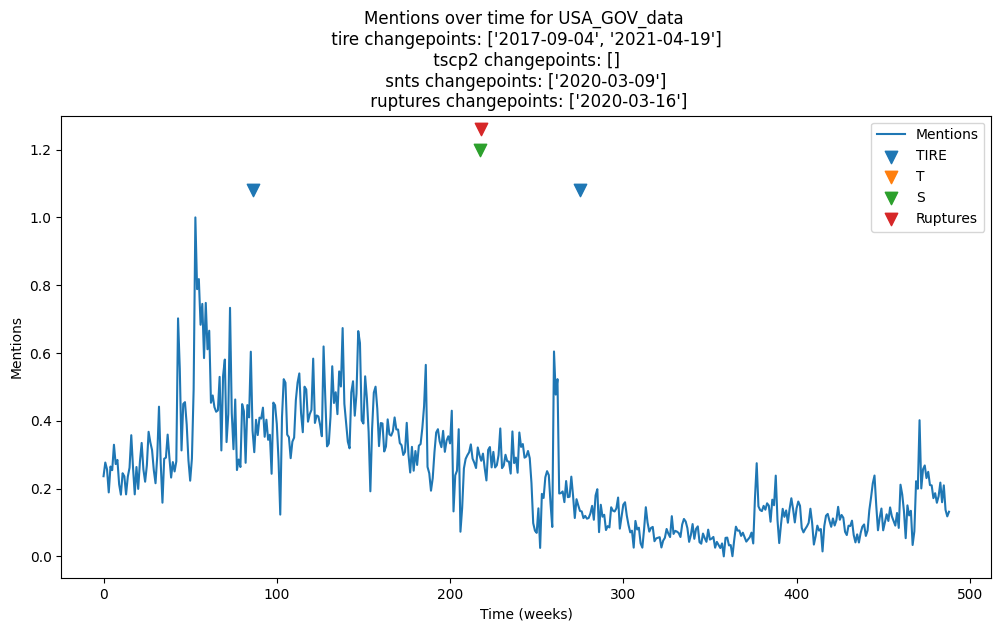

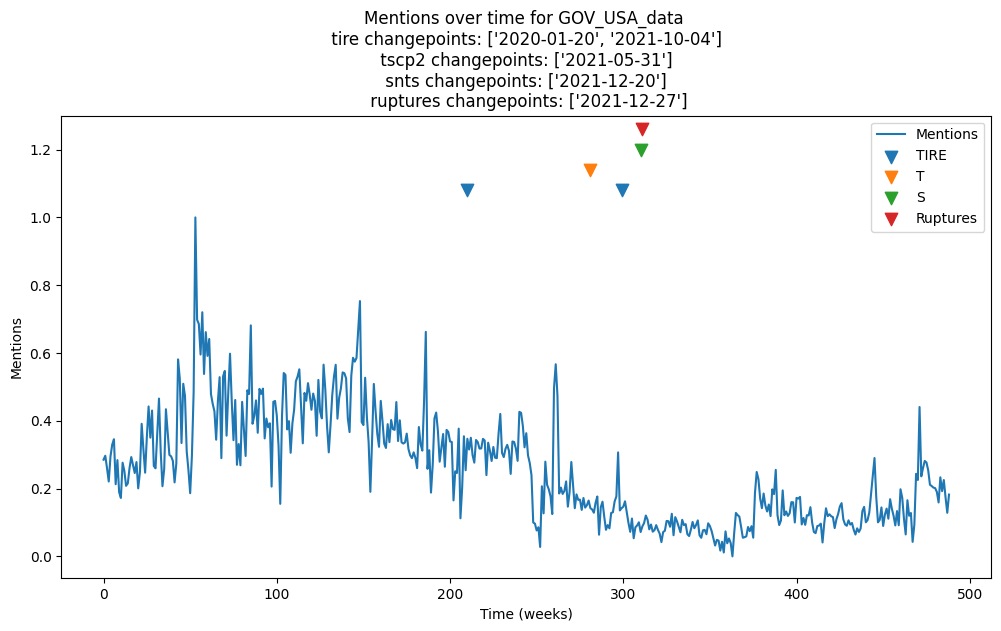

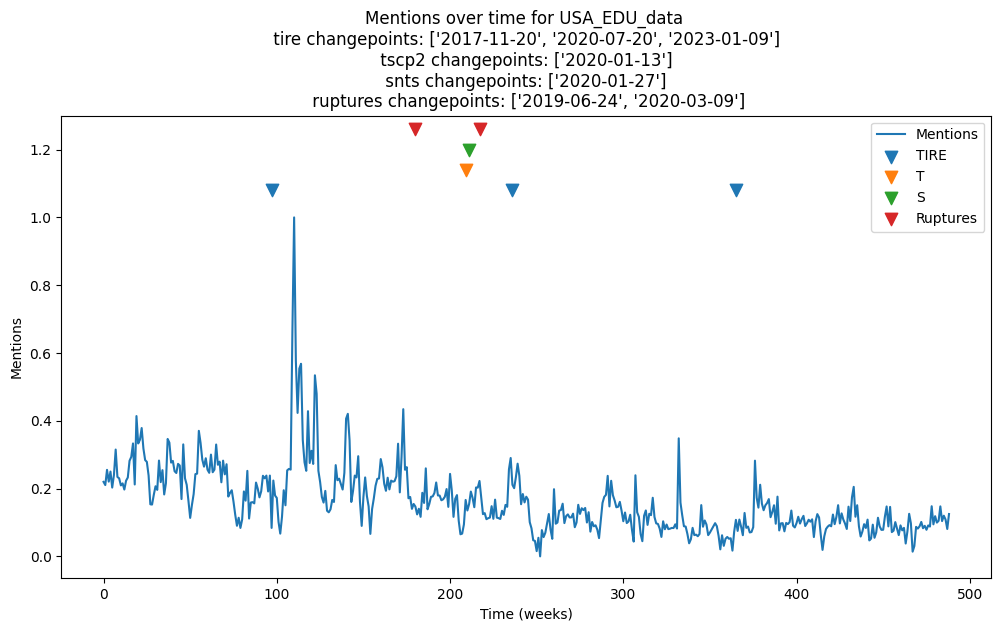

In [11]:
for _, pair in top_5_by_type["INST-GEO"].iterrows():
    name = pair["name"]
    index = pair["index"]

    # Get changepoint indices
    tire_cp = np.flatnonzero(tire_cps[index])
    t_cp    = np.flatnonzero(t_zeros[index])
    s_cp    = np.flatnonzero(s_zeros[index])
    rupt_cp = np.flatnonzero(rpt_cps[index])

    df = pd.read_csv(data_dir / f"{name}.csv")

    fig, ax = plt.subplots(figsize=(12, 6))

    # Main time series
    # normalize the series for better visualization
    ax.plot(minmax(df["mentions"]), label="Mentions")
    #ax.plot(minmax(df["avg_len"]), label="Average Length")
    #ax.plot(minmax(df["avg_tone"]), label="Average Tone")
    #ax.plot(minmax(df["avg_root_event"]), label="Average Root Event")

    # Changepoints as markers at different vertical positions
    ymax = 1

    ax.scatter(tire_cp, [ymax * 1.08] * len(tire_cp),
               marker="v", s=80, label="TIRE")

    ax.scatter(t_cp, [ymax * 1.14] * len(t_cp),
               marker="v", s=80, label="T")

    ax.scatter(s_cp, [ymax * 1.20] * len(s_cp),
               marker="v", s=80, label="S")

    ax.scatter(rupt_cp, [ymax * 1.26] * len(rupt_cp),
               marker="v", s=80, label="Ruptures")

    ax.set_ylim(top=ymax * 1.3)

    ax.set_title(f"Mentions over time for {name} \n tire changepoints: {[df['week'].iloc[i] for i in tire_cp]} \n tscp2 changepoints: {[df['week'].iloc[i] for i in t_cp]} \n snts changepoints: {[df['week'].iloc[i] for i in s_cp]} \n ruptures changepoints: {[df['week'].iloc[i] for i in rupt_cp]}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Mentions")
    ax.legend()

    plt.show()

In [12]:
file_names = [f.name for f in data_dir.iterdir() if f.is_file()]

In [13]:
top_mnt = np.argpartition(mean_mentions, -25)[-25:]
[file_names[i] for i in top_mnt]

['GBR_GOV_data.csv',
 'GOV_GBR_data.csv',
 'USA_MIL_data.csv',
 'USA_RUS_data.csv',
 'MED_USA_data.csv',
 'PSE_ISR_data.csv',
 'BUS_USA_data.csv',
 'USAMED_USA_data.csv',
 'USA_MED_data.csv',
 'ISR_PSE_data.csv',
 'CVL_USA_data.csv',
 'LEG_USA_data.csv',
 'EDU_USA_data.csv',
 'USA_BUS_data.csv',
 'USA_LEG_data.csv',
 'USA_JUD_data.csv',
 'USA_CVL_data.csv',
 'USAGOV_USA_data.csv',
 'COP_USA_data.csv',
 'USA_EDU_data.csv',
 'USA_USAGOV_data.csv',
 'JUD_USA_data.csv',
 'USA_COP_data.csv',
 'GOV_USA_data.csv',
 'USA_GOV_data.csv']

In [14]:
np.argpartition(min_mentions, -10)[-10:]

array([130,  60, 201, 203, 190, 218, 177, 188, 109, 195])

In [15]:
# Index 205, 182, 107, 130, 173, 175, 218, 188, 39, 177, 59, 190
# USA_USAGOV, USA_GOV, GOV_USA, JUD_USA, USA_COP, USA_CVL, USAGOV_USA, USA_JUD, COP_USA, USA_EDU, EDU_USA, USA_LEG

In [16]:
# Taxonomy of features:
# Coverage: mentions, events, avg_sentenceid, avg_a1co, avg_a2co, avg_actco, avg_root_event, avg_len
# Geograph: avg_lat1, avg_lon1, avg_lat2, avg_lon2
# Meta: total_num_mentions, total_num_sources, total_num_articles
# tone: avg_goldstein, avg_tone
# other: avg_confidence, avg_raw_text

In [17]:
feature_taxonomy = {"position": ["avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_len"],
                    "root_event": ["avg_root_event"],
                    "lat": ["avg_lat1", "avg_lat2", "avg_lata"],
                    "lon": ["avg_lon1", "avg_lon2", "avg_lona"],
                    "volume": ["total_num_mentions", "total_num_sources", "total_num_articles", "mentions", "events"],
                    "tone": ["avg_goldstein", "avg_tone"],
                    "meta": ["avg_confidence", "avg_raw_text"]}

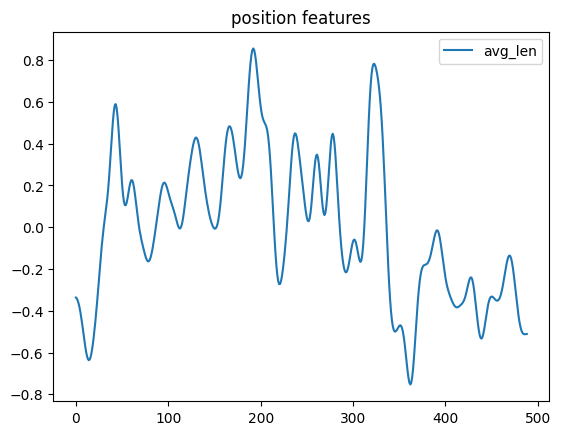

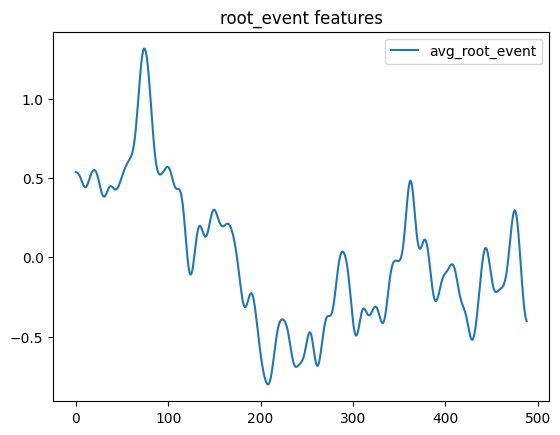

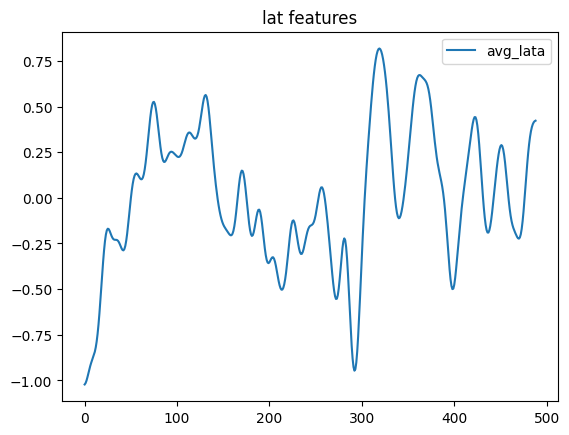

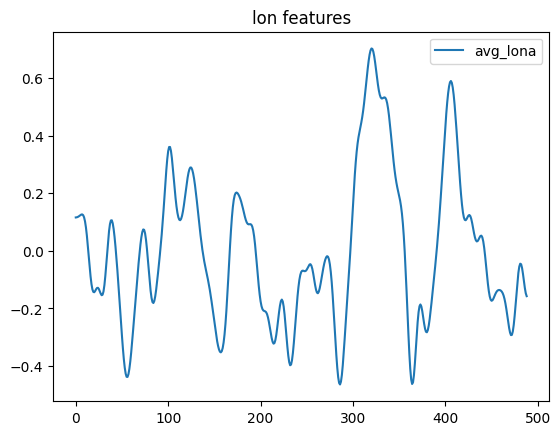

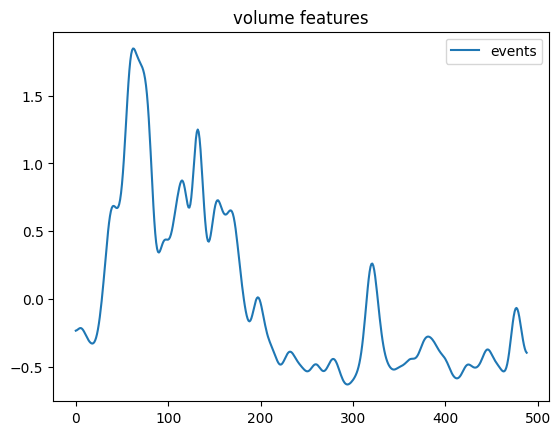

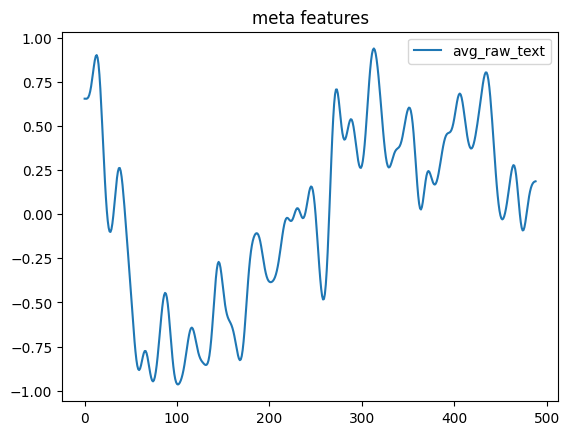

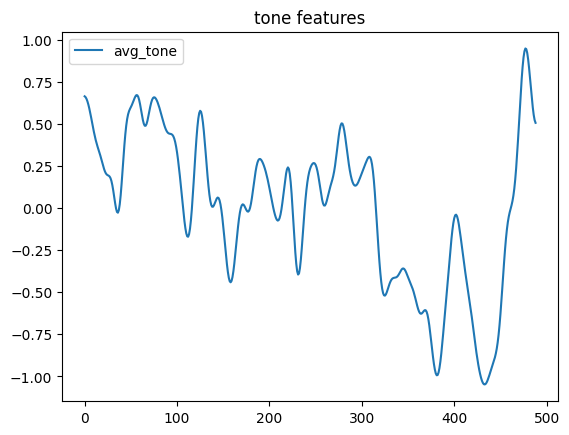

In [18]:
ex1 = pd.read_csv("D:/gdelt_data/input_datasets/weekly_pw_filtered_features/RUS_USA_data.csv")

for category in ["position", "root_event", "lat", "lon", "volume", "meta", "tone"]:
    plt.figure()
    xs = []
    for feature in feature_taxonomy[category]:
        x = ex1[feature].to_numpy()
        x = (x - x.mean()) / x.std()
        xs.append(x)
    xs = np.array(xs)
    x = np.mean(xs, axis=0)
    plt.plot(gaussian_filter(x, sigma=5), label=feature)
    plt.title(f"{category} features")
    plt.legend()
    plt.show()

## Feature correlation

In [19]:
feature_1 = all_data[:,:,1].ravel()
feature_2 = all_data[:,:,2].ravel()

In [20]:
F = all_data.transpose(2, 0, 1).reshape(all_data.shape[2], -1)
corr = np.corrcoef(F)

In [21]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
import seaborn as sns

dist = 1 - abs(corr)
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0)

Z = linkage(squareform(dist), method="average")
labels = fcluster(Z, t=6, criterion="maxclust") #distance, maxclust
labels

array([4, 4, 6, 6, 6, 6, 3, 6, 6, 5, 5, 3, 1, 2, 1, 2, 1, 2, 4, 4, 4],
      dtype=int32)

In [22]:
for i in range(np.max(labels)):
    print(f"Cluster {i + 1}")
    for j, obj in enumerate(labels):
        if obj == i + 1:
            print(cols[j])
    print("---")

Cluster 1
avg_lat1
avg_lat2
avg_lata
---
Cluster 2
avg_lon1
avg_lon2
avg_lona
---
Cluster 3
avg_raw_text
avg_confidence
---
Cluster 4
mentions
events
total_num_mentions
total_num_sources
total_num_articles
---
Cluster 5
avg_goldstein
avg_tone
---
Cluster 6
avg_sentenceid
avg_a1co
avg_a2co
avg_actco
avg_root_event
avg_len
---


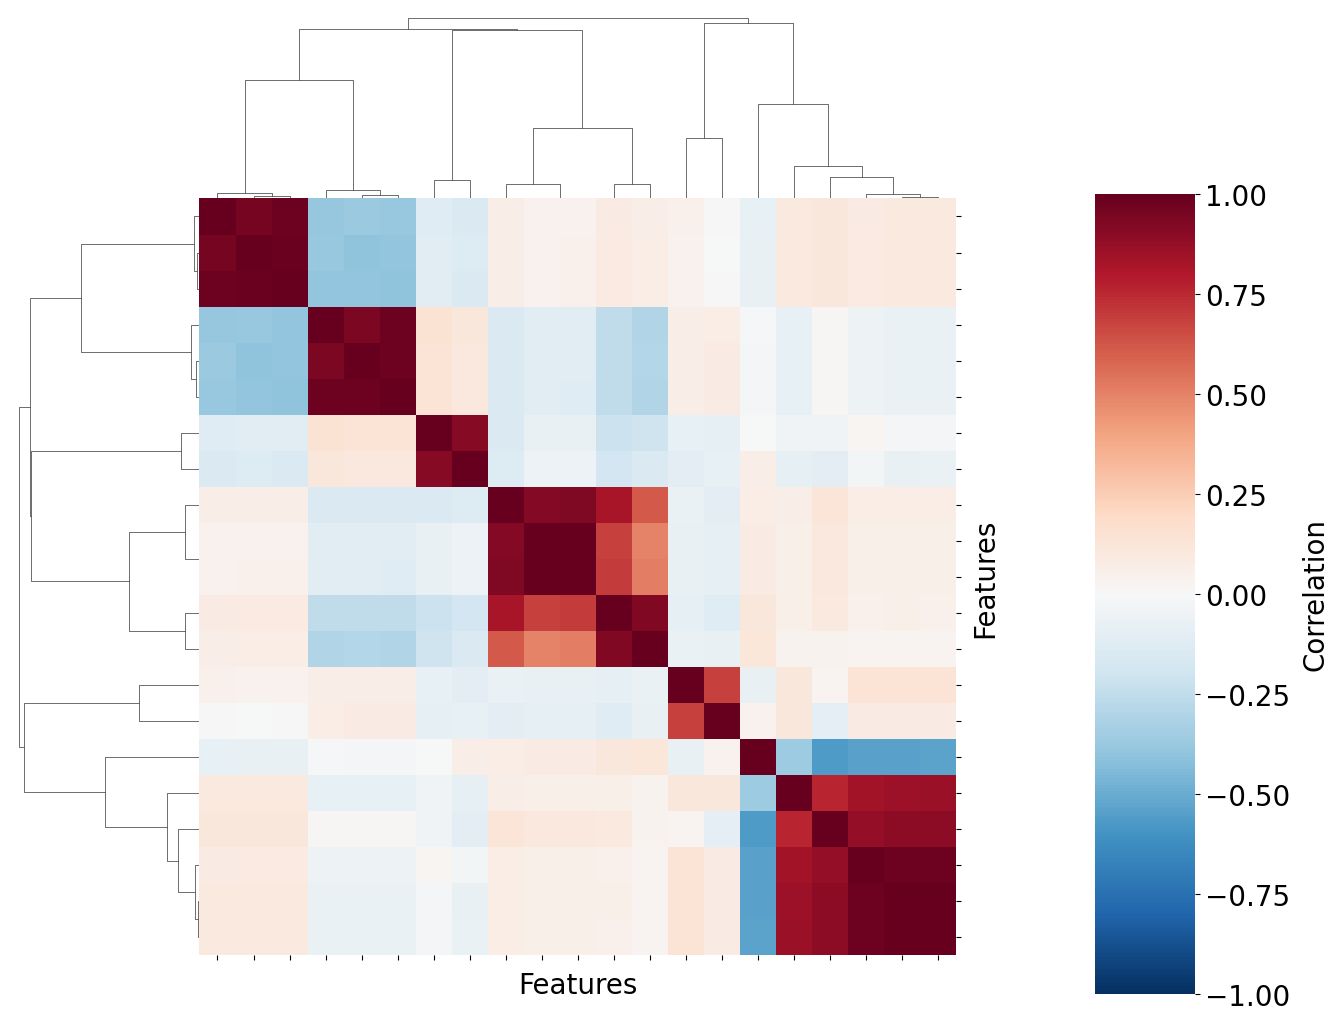

In [38]:
g = sns.clustermap(
    corr,
    row_linkage=Z,
    col_linkage=Z,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(10, 10),
    linewidths=0,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Correlation"}
)

g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel("")

g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel("")

# Feature labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=20
)

plt.setp(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=20
)

g.ax_heatmap.set_xlabel("Features", fontsize=20)
g.ax_heatmap.set_ylabel("Features", fontsize=20)

# -------------------------------
# Correlation colorbar
# -------------------------------

# [left, bottom, width, height]
g.cax.set_position([1.1, 0, 0.1, 0.8])

g.cax.tick_params(labelsize=20  )

g.cax.set_ylabel(
    "Correlation",
    fontsize=20,
    labelpad=8
)

plt.show()